# $h_+$ from `one_k_tensor.ini`

Run `./class one_k_tensor.ini` first. This notebook loads the `output/one_k_tensor_00_*` files and plots the tensor mode, bypassing `classy` entirely.

Column layout (scalar perturbations file) — see header of `output/one_k_tensor_00_perturbations_k0_s.dat`:
`1:tau  2:a  ...  28:h_+  29:d(h_+)  30:h_x  31:d(h_x)`

In [1]:
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
%matplotlib widget

run = '../../output/one_k_tensor_00'
mass_eV = 1e-25
gammak = np.pi/2
h = 0.6688
colors = ['b', 'brown', 'r', 'g', 'purple', 'orange']

In [2]:
# --- background ---
bg = np.loadtxt(f'{run}_background.dat')
bg_z      = bg[:, 0]
bg_a      = 1./(1.+bg_z)
bg_H      = bg[:, 3]        # H [1/Mpc]
bg_sigmaA = bg[:, 21]       # sigma_A [1/Mpc]

# a_osc: where H/m = 1
m_Mpc = mass_eV * 1.56373846613383e29
a_osc = float(interp1d(bg_H / m_Mpc, bg_a)(1.0))
print(f'a_osc = {a_osc:.4e}')

FileNotFoundError: ../../output/one_k_tensor_00_background.dat not found.

In [ ]:
# --- auto-detect every k mode written by CLASS ---
# Each file's first line is: "#scalar perturbations for mode k = <value> Mpc^(-1)"
_k_header = re.compile(r'k\s*=\s*([\d.eE+-]+)')

def _read_k(path):
    with open(path) as fh:
        return float(_k_header.search(fh.readline()).group(1))

pert_files = sorted(
    glob.glob(f'{run}_perturbations_k*_s.dat'),
    key=lambda p: int(re.search(r'_k(\d+)_s\.dat$', p).group(1)),
)
k_out = [_read_k(p) for p in pert_files]
pert  = [np.loadtxt(p) for p in pert_files]
print(f'loaded {len(k_out)} k modes: ' + ', '.join(f'{k:.3g}' for k in k_out))

# column indices (1-based in header, 0-based here)
COL_A, COL_HPLUS, COL_DHPLUS, COL_HX = 1, 27, 28, 29

loaded 4 k modes: 0.0001, 0.001, 0.01, 40


## $h_+$

/tmp/ipykernel_9517/1545601243.py:34: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_9517/1545601243.py:35: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f'../../Figures/h_+_m={int(np.log10(mass_eV))}_ini.pdf')
/home/tomas/miniconda3/envs/class_env/lib/python3.9/site-packages/ipympl/backend_nbagg.py:335: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self.figure.savefig(buf, format='png', dpi='figure')


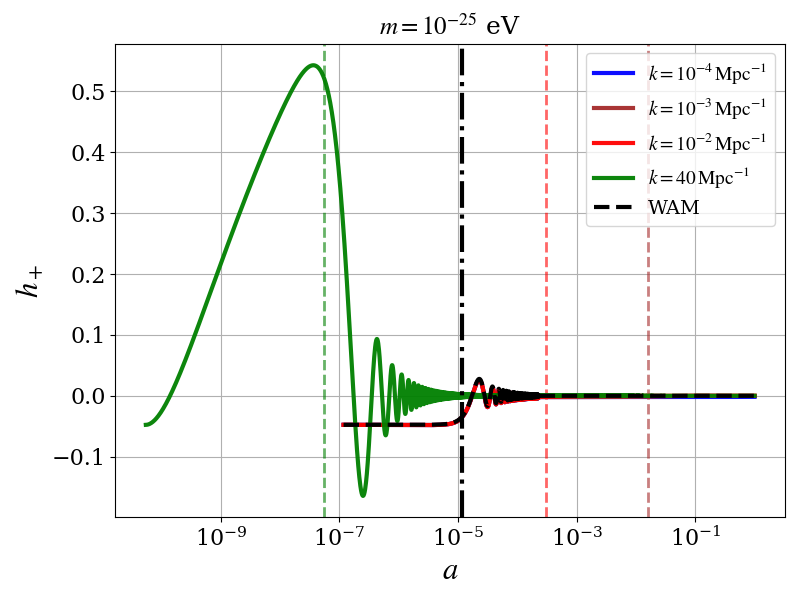

In [ ]:
def k_label(k):
    lg = np.log10(k)
    if np.isclose(lg, round(lg)):
        return rf'$k = 10^{{{int(round(lg))}}}\,\mathrm{{Mpc}}^{{-1}}$'
    return rf'$k = {k:g}\,\mathrm{{Mpc}}^{{-1}}$'

plt.figure(figsize=(8, 6))
for k_idx, (k_val, data) in enumerate(zip(k_out, pert)):
    a  = data[:, COL_A]
    hp = data[:, COL_HPLUS]
    plt.semilogx(a, hp, colors[k_idx], lw=3, alpha=0.95, label=k_label(k_val))

    # horizon crossing k = aH
    try:
        a_cross = float(interp1d(k_val / (bg_H * bg_a), bg_a)(1.0))
        plt.axvline(a_cross, color=colors[k_idx], ls='dashed', lw=2, alpha=0.6)
    except ValueError:
        pass

# WAM reference (Weinberg adiabatic mode): h_+ ~ sigma_A / (aH)
a_ref = pert[0][:, COL_A]
weinberg = interp1d(bg_a, 0.75 * np.sin(gammak)**2 * bg_sigmaA / (bg_H * bg_a))(a_ref)
hp0 = pert[0][:, COL_HPLUS]
plt.semilogx(a_ref, (hp0[0] - weinberg[0]) + weinberg, 'k--', lw=3, label='WAM')

plt.axvline(a_osc, color='k', ls='dashdot', lw=3)
plt.xlabel(r'$a$', size=22)
plt.ylabel(r'$h_+$', size=22)
#plt.xlim(a_ref[0], 1.)
plt.tick_params(labelsize=16)
plt.title(rf'$m = 10^{{{int(np.log10(mass_eV))}}}$ eV', fontsize=18)
plt.legend(fontsize=14)
plt.grid()
plt.tight_layout()
plt.savefig(f'../../Figures/h_+_m={int(np.log10(mass_eV))}_ini.pdf')
plt.show()

## $d h_+$

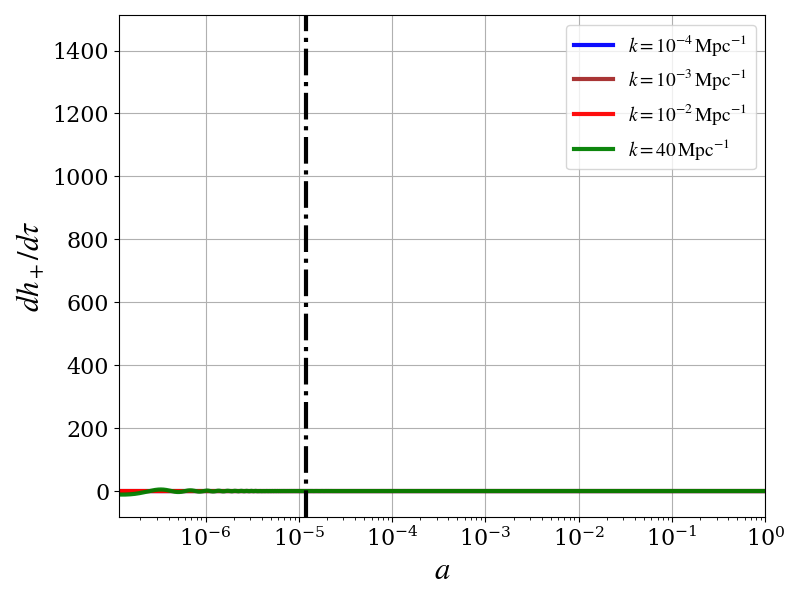

In [ ]:
plt.figure(figsize=(8, 6))
for k_idx, (k_val, data) in enumerate(zip(k_out, pert)):
    a   = data[:, COL_A]
    dhp = data[:, COL_DHPLUS]
    plt.semilogx(a, dhp, colors[k_idx], lw=3, alpha=0.95, label=k_label(k_val))

plt.axvline(a_osc, color='k', ls='dashdot', lw=3)
plt.xlabel(r'$a$', size=22)
plt.ylabel(r'$d h_+/d\tau$', size=22)
plt.xlim(pert[0][0, COL_A], 1.)
plt.tick_params(labelsize=16)
plt.legend(fontsize=14)
plt.grid()
plt.tight_layout()
plt.show()

## $h_\times$

In [ ]:
plt.figure(figsize=(8, 6))
for k_idx, (k_val, data) in enumerate(zip(k_out, pert)):
    a  = data[:, COL_A]
    hx = data[:, COL_HX]
    plt.semilogx(a, hx, colors[k_idx], lw=3, alpha=0.95, label=k_label(k_val))

plt.axvline(a_osc, color='k', ls='dashdot', lw=3)
plt.xlabel(r'$a$', size=22)
plt.ylabel(r'$h_\times$', size=22)
plt.xlim(pert[0][0, COL_A], 1.)
plt.tick_params(labelsize=16)
plt.legend(fontsize=14)
plt.grid()
plt.tight_layout()
plt.show()